Epoch 1/200


C:\Users\wang\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.2590 - loss: 13.5410 - val_accuracy: 0.5909 - val_loss: 12.7650 - learning_rate: 8.0000e-04
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.7191 - loss: 12.5542 - val_accuracy: 0.3409 - val_loss: 13.7196 - learning_rate: 8.0000e-04
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.8292 - loss: 12.4580 - val_accuracy: 0.2727 - val_loss: 14.5514 - learning_rate: 8.0000e-04
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.9369 - loss: 12.0656 - val_accuracy: 0.2727 - val_loss: 14.7668 - learning_rate: 8.0000e-04
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.9316 - loss: 11.7024 - val_accuracy: 0.1591 - val_loss: 14.8112 - learning_rate: 8.0000e-04
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.9516 - loss: 11.0232 - val_accuracy: 0.1364 - val_loss: 14.6550 - learning_rate: 8.0000e-04
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - acc

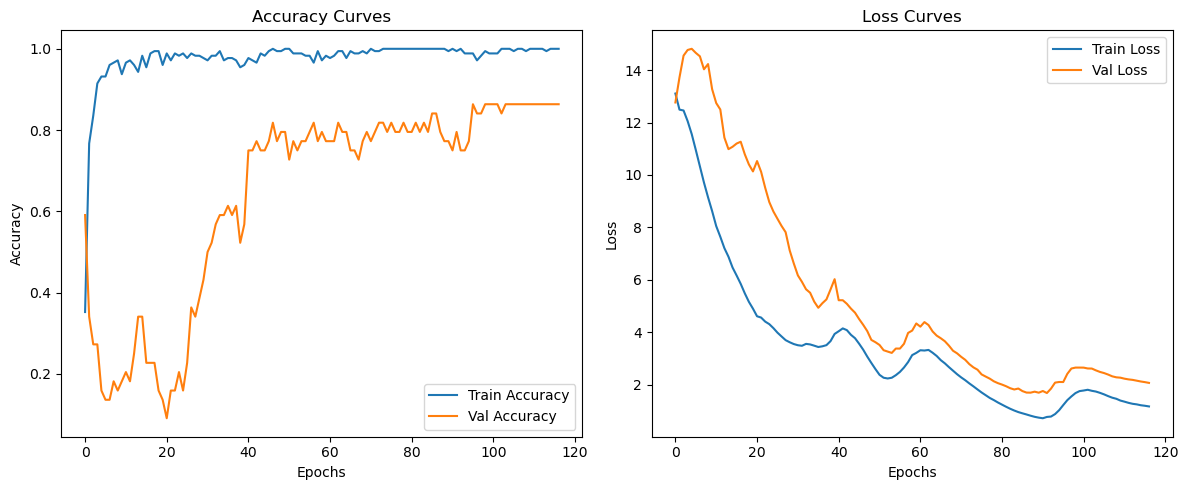

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


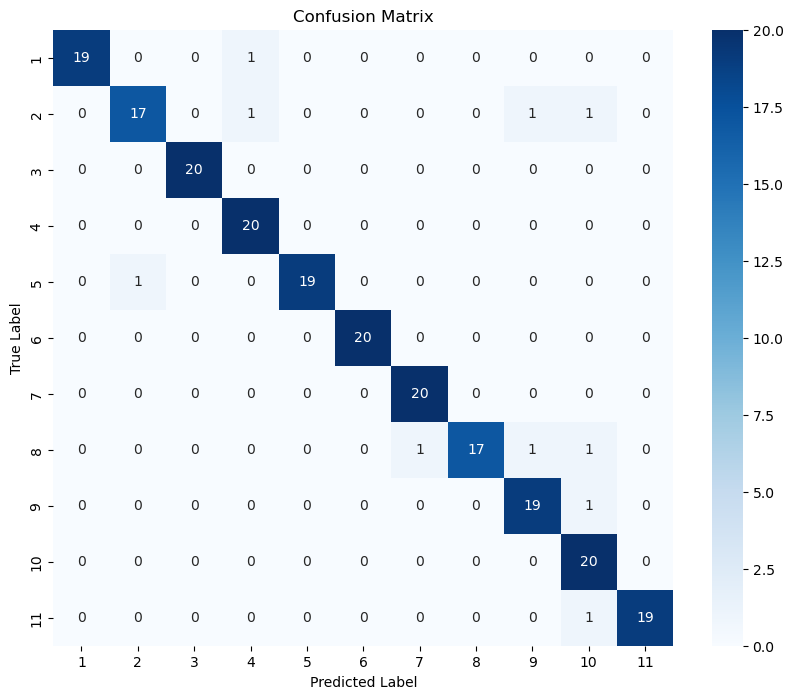


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        20
           2       0.94      0.85      0.89        20
           3       1.00      1.00      1.00        20
           4       0.91      1.00      0.95        20
           5       1.00      0.95      0.97        20
           6       1.00      1.00      1.00        20
           7       0.95      1.00      0.98        20
           8       1.00      0.85      0.92        20
           9       0.90      0.95      0.93        20
          10       0.83      1.00      0.91        20
          11       1.00      0.95      0.97        20

    accuracy                           0.95       220
   macro avg       0.96      0.95      0.95       220
weighted avg       0.96      0.95      0.95       220

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


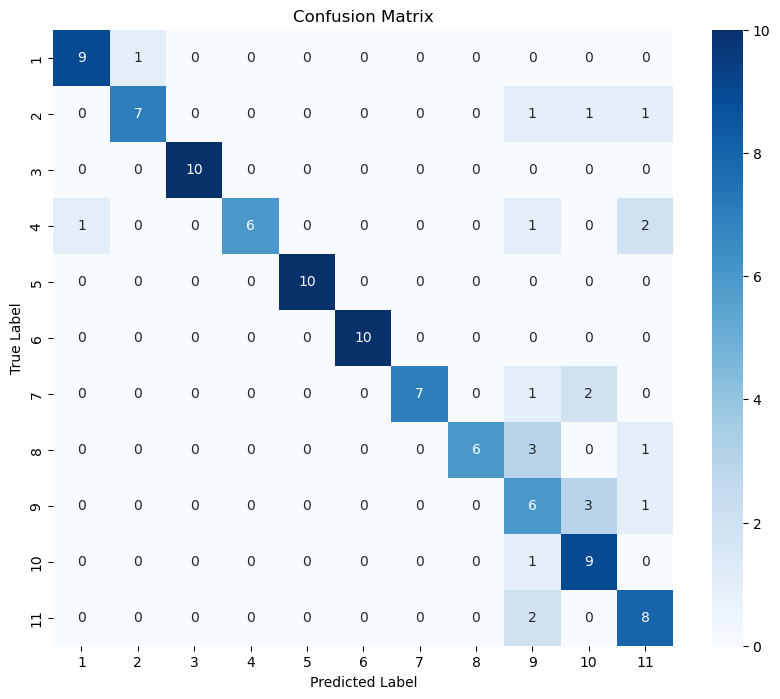


Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.90      0.90        10
           2       0.88      0.70      0.78        10
           3       1.00      1.00      1.00        10
           4       1.00      0.60      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      0.70      0.82        10
           8       1.00      0.60      0.75        10
           9       0.40      0.60      0.48        10
          10       0.60      0.90      0.72        10
          11       0.62      0.80      0.70        10

    accuracy                           0.80       110
   macro avg       0.85      0.80      0.81       110
weighted avg       0.85      0.80      0.81       110



In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# 数据加载与预处理 ----------------------------------------------------
def load_data(file_path):
    # 读取无表头CSV文件
    df = pd.read_excel(file_path, header=None)

    # 分割特征和标签（最后一列为标签）
    X = df.iloc[:, :-1].values.astype("float32")  # 前899列为特征
    y = df.iloc[:, -1].values.astype("int32") - 1  # 标签转换为0-10

    # 标准化特征
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 重塑为CNN输入格式 (样本数, 时间步长, 特征维度)
    X_reshaped = X_scaled.reshape(-1, 899, 1)

    return X_reshaped, y


# 增强型1D CNN模型 ---------------------------------------------------
def build_cnn_model(input_shape):
    model = Sequential()

    # 特征提取模块
    model.add(Conv1D(64, 7, activation="relu", padding="same", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.3))

    model.add(Conv1D(128, 5, activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.4))

    model.add(Conv1D(256, 3, activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.5))

    # 分类模块
    model.add(Flatten())
    model.add(Dense(512, activation="relu", kernel_regularizer="l2"))
    model.add(BatchNormalization())
    model.add(Dropout(0.6))

    model.add(Dense(11, activation="softmax"))

    # 自定义优化器
    optimizer = Adam(learning_rate=0.0008, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# 训练与评估流程 -----------------------------------------------------
def train_and_evaluate(file_path):
    # 加载数据
    X, y = load_data(file_path)

    # 划分数据集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1/3, random_state=42, stratify=y
    )

    # 构建模型
    model = build_cnn_model(input_shape=(899, 1))

    # 训练回调
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=1),
    ]

    # 训练模型
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=callbacks,
        verbose=1,
    )

    # 评估模型
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    # 可视化
    plot_training_curves(history)
    plot_confusion_matrix(model, X_train, y_train)
    plot_confusion_matrix(model, X_test, y_test)
    return model


# 可视化工具 --------------------------------------------------------
def plot_training_curves(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(model, X, y_true):
    y_pred = np.argmax(model.predict(X), axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(1, 12),
        yticklabels=range(1, 12),
    )
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("\nClassification Report:")
    print(
        classification_report(
            y_true, y_pred, target_names=[str(i) for i in range(1, 12)]
        )
    )


# 主程序 ------------------------------------------------------------
if __name__ == "__main__":
    # 替换为实际文件路径
    data_file = "手语数据汇总(330个数据).xlsx"

    # 训练评估模型
    trained_model = train_and_evaluate(data_file)

    # 保存模型
    trained_model.save("1d_cnn_classifier.h5")